### The data set has information about features of silhouette extracted from the images of different cars

Four "Corgie" model vehicles were used for the experiment: a double decker bus, Cheverolet van, Saab 9000 and an Opel Manta 400 cars. This particular combination of vehicles was chosen with the expectation that the bus, van and either one of the cars would be readily distinguishable, but it would be more difficult to distinguish between the cars.



In [63]:
import warnings 
warnings.filterwarnings('ignore')

In [149]:
import numpy as np
import pandas as pd
from scipy.stats import zscore
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import cophenet,dendrogram, linkage,fcluster
from scipy.spatial.distance import pdist  #Pairwise distribution between data points

In [65]:
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc

In [66]:
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

### 1. Read the dataset using function .dropna() - to avoid dealing with NAs as of now

In [67]:
#Read Vehicle Data
vehicle_df = pd.read_csv("vehicle.csv")

vehicle_df.head()


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [68]:
#Get Information about Vehicle dataset
vehicle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
compactness                    846 non-null int64
circularity                    841 non-null float64
distance_circularity           842 non-null float64
radius_ratio                   840 non-null float64
pr.axis_aspect_ratio           844 non-null float64
max.length_aspect_ratio        846 non-null int64
scatter_ratio                  845 non-null float64
elongatedness                  845 non-null float64
pr.axis_rectangularity         843 non-null float64
max.length_rectangularity      846 non-null int64
scaled_variance                843 non-null float64
scaled_variance.1              844 non-null float64
scaled_radius_of_gyration      844 non-null float64
scaled_radius_of_gyration.1    842 non-null float64
skewness_about                 840 non-null float64
skewness_about.1               845 non-null float64
skewness_about.2               845 non-null float64
hollows_ratio    

In [69]:
#Get Shape of Vehicle Data Frame
vehicle_df.shape

(846, 19)

In [70]:
#Check NA in the Vehicle Dataframe
vehicle_df.isna().sum()

compactness                    0
circularity                    5
distance_circularity           4
radius_ratio                   6
pr.axis_aspect_ratio           2
max.length_aspect_ratio        0
scatter_ratio                  1
elongatedness                  1
pr.axis_rectangularity         3
max.length_rectangularity      0
scaled_variance                3
scaled_variance.1              2
scaled_radius_of_gyration      2
scaled_radius_of_gyration.1    4
skewness_about                 6
skewness_about.1               1
skewness_about.2               1
hollows_ratio                  0
class                          0
dtype: int64

In [71]:
# drop row from Vehice Data frame if any column contains NA value.
vehicle_df.dropna(axis = 0, inplace=True)

In [163]:
#Get Shape of Vehicle Data Frame after removed NA rows
vehicle_df.shape

(813, 20)

In [164]:
#Check NA in the Vehicle Dataframe. After removed NA.
vehicle_df.isna().sum()

compactness                    0
circularity                    0
distance_circularity           0
radius_ratio                   0
pr.axis_aspect_ratio           0
max.length_aspect_ratio        0
scatter_ratio                  0
elongatedness                  0
pr.axis_rectangularity         0
max.length_rectangularity      0
scaled_variance                0
scaled_variance.1              0
scaled_radius_of_gyration      0
scaled_radius_of_gyration.1    0
skewness_about                 0
skewness_about.1               0
skewness_about.2               0
hollows_ratio                  0
class                          0
GROUP                          0
dtype: int64

### 2. Print/ Plot the dependent (categorical variable) - Class column

Since the variable is categorical, you can use value_counts function

In [165]:
vehicle_df["class"].value_counts()

car    413
bus    205
van    195
Name: class, dtype: int64

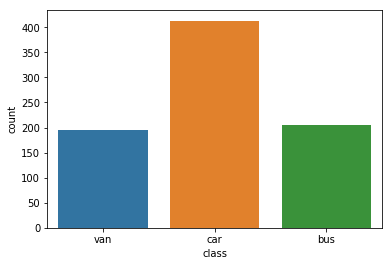

In [166]:
plot = sns.countplot(x = "class", data = vehicle_df)
plot.set_xticklabels(plot.get_xticklabels());

### Check for any missing values in the data 

In [167]:
#Check any missing value
vehicle_df.isnull().values.any()

False

### 3. Standardize the data 

In [168]:
#Since 'Class' colmn is categorical column. Lets remove for the scalling (zscore).

numeric_cols = vehicle_df.drop('class', axis=1)

class_col  = vehicle_df.pop("class")

numeric_cols = numeric_cols.apply(zscore)

vehicle_df = numeric_cols.join(class_col)   # Recreating mpg_df by combining numerical columns with car names

vehicle_df.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,GROUP,class
0,0.163231,0.520408,0.060669,0.264970,1.283254,0.299721,-0.198517,0.129648,-0.217151,0.766312,-0.397397,-0.339014,0.301676,-0.321192,-0.071523,0.371287,-0.321809,0.171837,1.317510,van
1,-0.322874,-0.619123,0.124067,-0.836393,-0.599253,0.085785,-0.591720,0.514333,-0.606014,-0.337462,-0.590034,-0.618754,-0.502972,-0.053505,0.538425,0.147109,0.003400,0.442318,1.317510,van
2,1.256966,0.845988,1.518823,1.187734,0.530251,0.299721,1.162569,-1.152637,0.949438,0.697326,1.111591,1.122486,1.415804,0.080339,1.555006,-0.413338,-0.159204,0.036596,-0.275257,car
3,-0.079822,-0.619123,-0.002729,-0.300595,0.153750,0.085785,-0.742952,0.642562,-0.606014,-0.337462,-0.911095,-0.738643,-1.462359,-1.258099,-0.071523,-0.301249,1.629444,1.524243,1.317510,van
4,-1.052030,-0.130753,-0.763506,1.068668,5.173770,9.285029,-0.591720,0.514333,-0.606014,-0.268476,1.689501,-0.647299,0.425468,7.307905,0.538425,-0.189159,-1.460039,-1.721531,0.521127,bus


Since the dimensions of the data are not really known to us, it would be wise to standardize the data using z scores before we go for any clustering methods.
You can use zscore function to do this

### K - Means Clustering

### 4. Assign a dummy array called distortion

In [169]:
#Finding optimal no. of clusters
from scipy.spatial.distance import cdist

meanDistortions=[]

You can later use this array to plot the elbow plot

### 5. Calculating distortion - C distance

Iterating values of k from 1 to 10 fit K means model
Using c distance - Get the measure for Sum of squares error.

In [170]:
vehicle_df_attributes = vehicle_df.drop("class",axis=1)
clusters=range(1,10)

for k in clusters:
    model=KMeans(n_clusters=k)
    model.fit(vehicle_df_attributes)
    prediction=model.predict(vehicle_df_attributes)
    meanDistortions.append(sum(np.min(cdist(vehicle_df_attributes, model.cluster_centers_, 'euclidean'), axis=1)) / vehicle_df_attributes.shape[0])
    

meanDistortions
    

[4.092536656107178,
 3.136690418750311,
 2.6454239618910087,
 2.55085507119089,
 2.437667688002857,
 2.350332333120689,
 2.269235361429504,
 2.2019995803303902,
 2.1396758371626943]

### 6. Plotting Elbow/ Scree Plot

Text(0.5, 1.0, 'Selecting k with the Elbow Method')

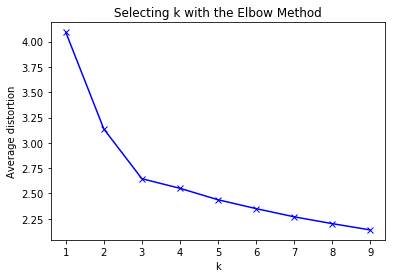

In [171]:
plt.plot(clusters, meanDistortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Average distortion')
plt.title('Selecting k with the Elbow Method')

Use Matplotlib to plot the scree plot - Note: Scree plot plots distortion vs the no of clusters

### Find out the optimal value of K

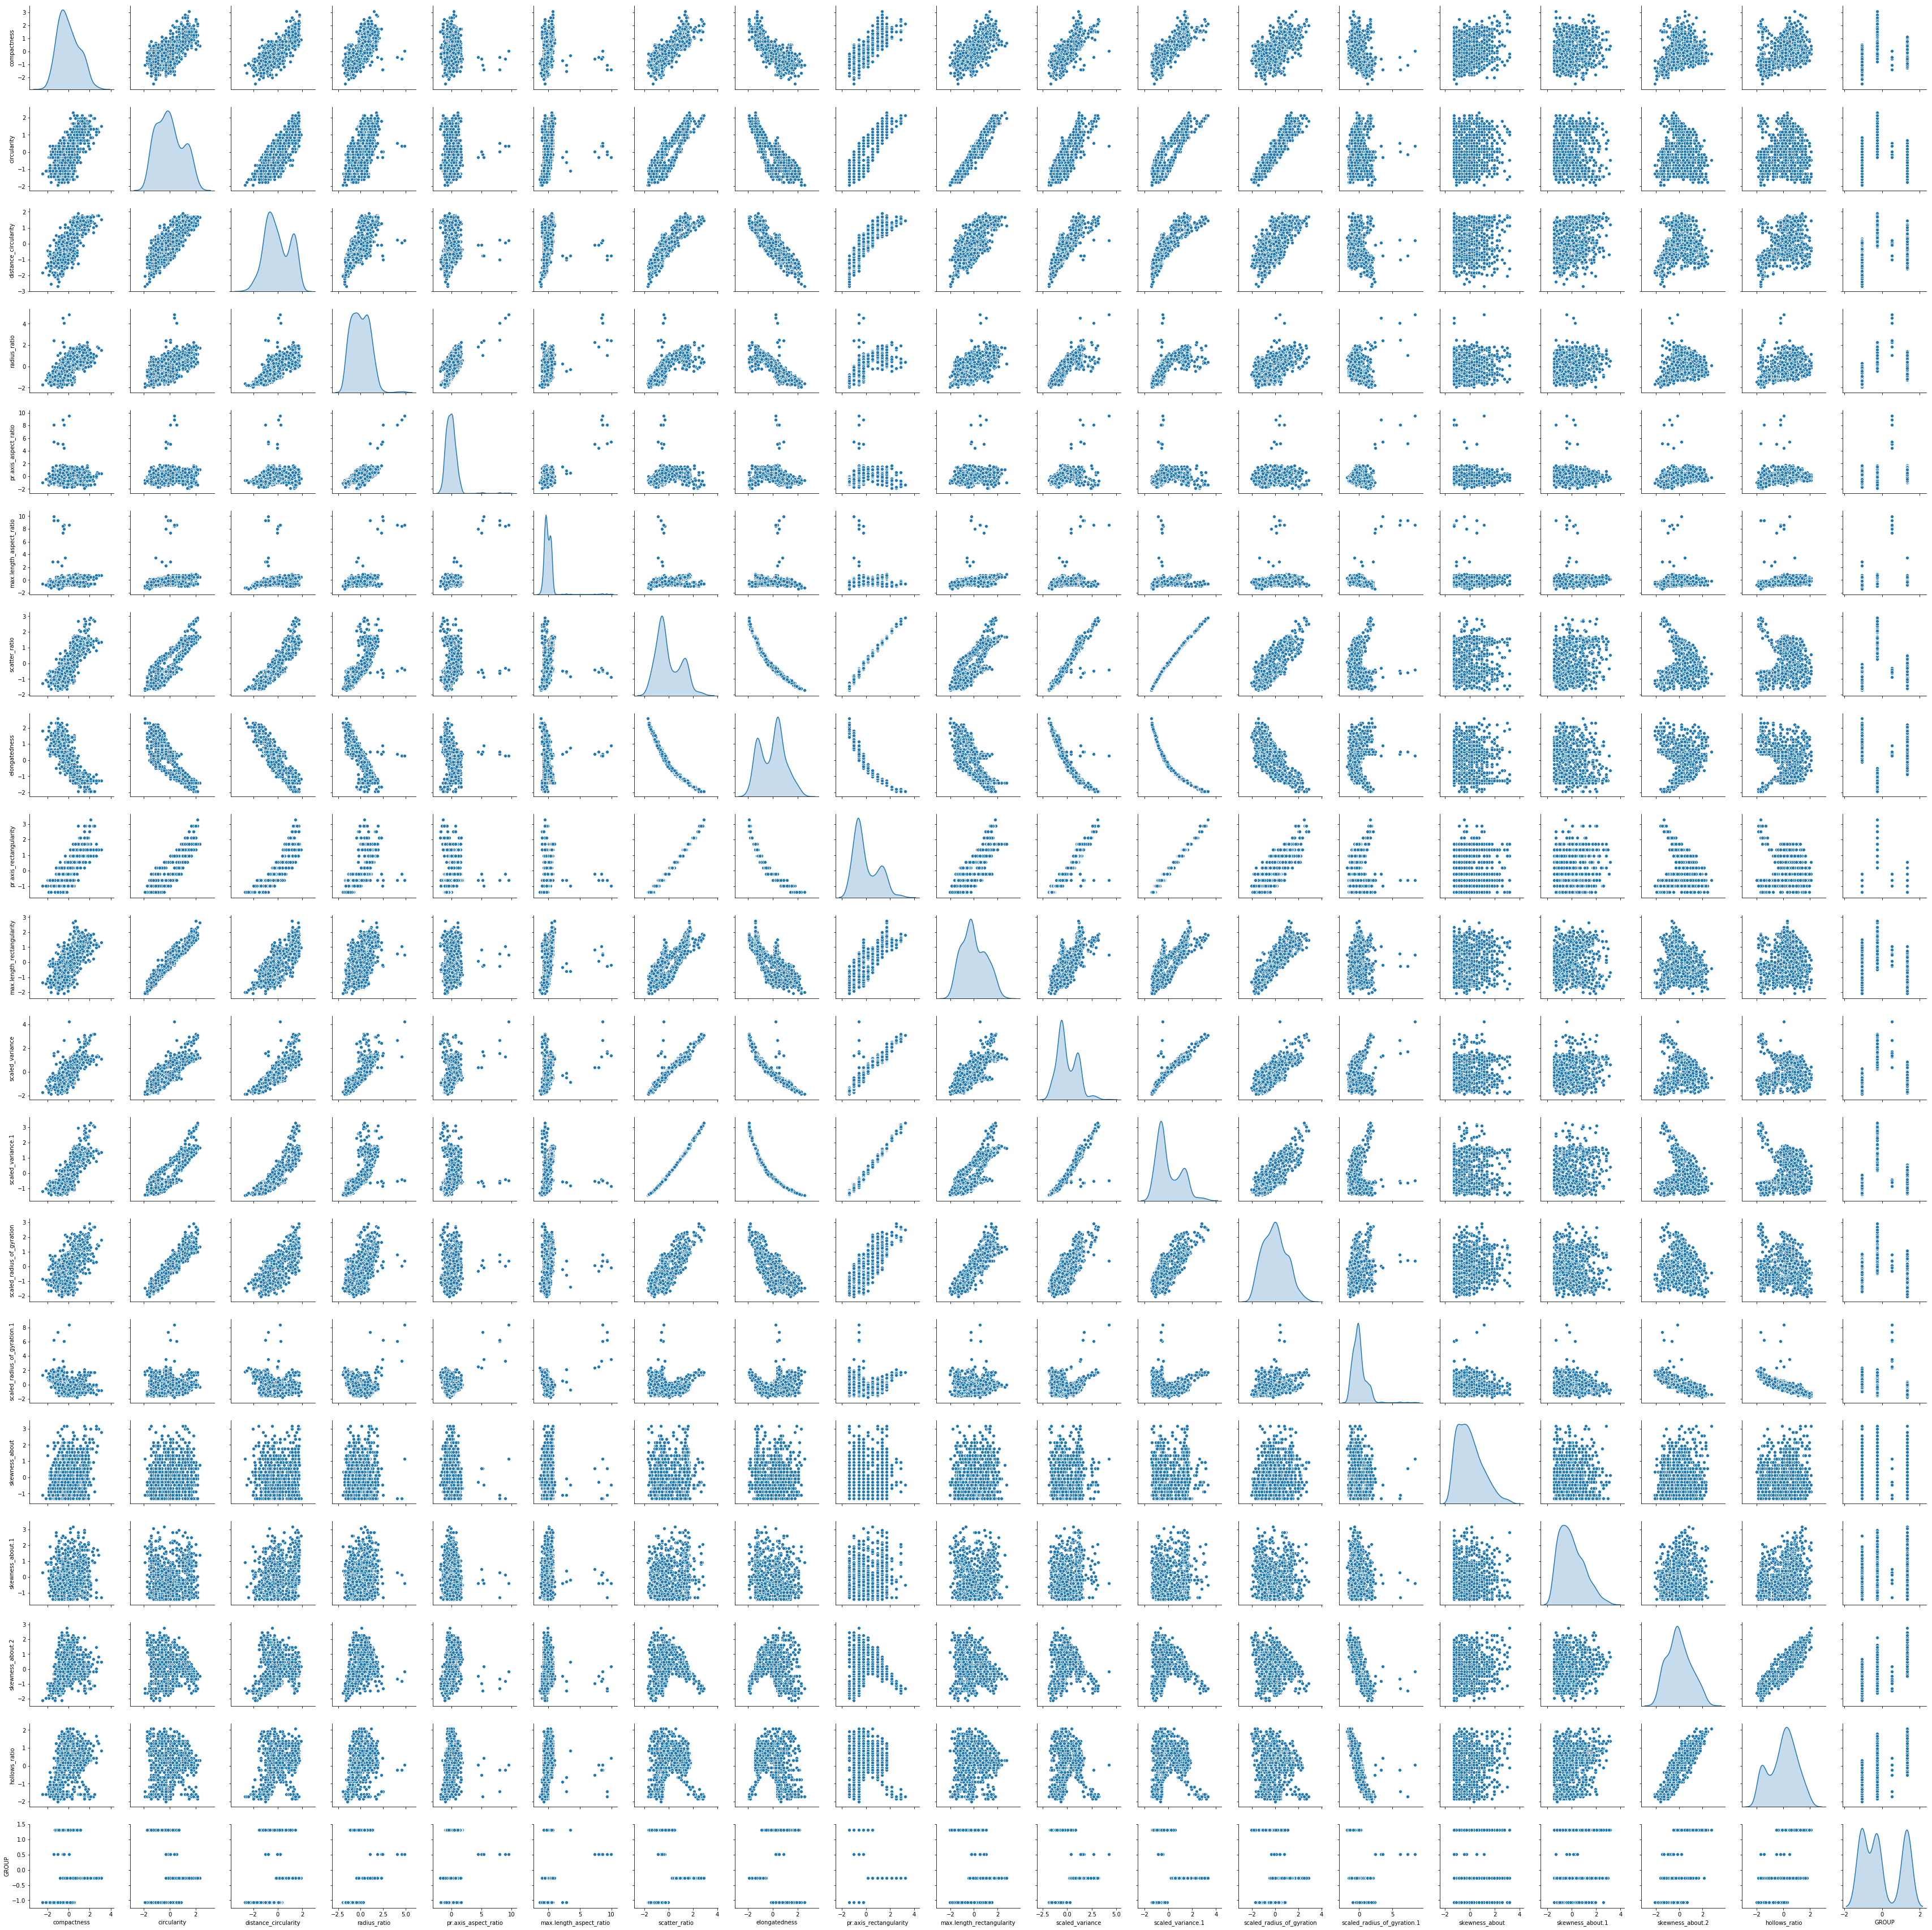

In [172]:
#Let us do a pair plot analysis to visually check number of likely clusters
sns.pairplot(vehicle_df_attributes, diag_kind='kde')

In [173]:
cluster_range = range( 2, 6 )   # expect 3 to 4 clusters from the pair panel visual inspection hence restricting from 2 to 6
cluster_errors = []
for num_clusters in cluster_range:
  clusters = KMeans( num_clusters, n_init = 5)
  clusters.fit(vehicle_df_attributes)
  labels = clusters.labels_
  centroids = clusters.cluster_centers_
  cluster_errors.append( clusters.inertia_ )
clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "cluster_errors": cluster_errors } )
clusters_df[0:15]

,num_clusters,cluster_errors
0,2,9427.539774
1,3,7049.058999
2,4,6529.835954
3,5,5271.973434


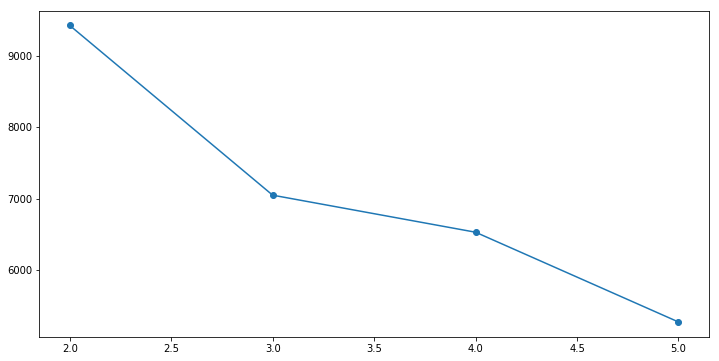

In [174]:
# Elbow plot

plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

In [96]:
### The elbow plot confirms our visual analysis that there are likely 3 or 4 good clusters

In [175]:
# Let us first start with K = 4
final_model=KMeans(4)
final_model.fit(vehicle_df_attributes)
prediction=final_model.predict(vehicle_df_attributes)

centroids = final_model.cluster_centers_

#Append the prediction 
vehicle_df["GROUP"] = prediction
print("Groups Assigned : \n")
vehicle_df[["class", "GROUP"]]

Groups Assigned : 



,class,GROUP
0,van,2
1,van,2
2,car,1
3,van,2
4,bus,3
6,bus,2
7,van,2
8,van,2
10,van,2
11,car,2


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000000002BAA42E8>,
      dtype=object)

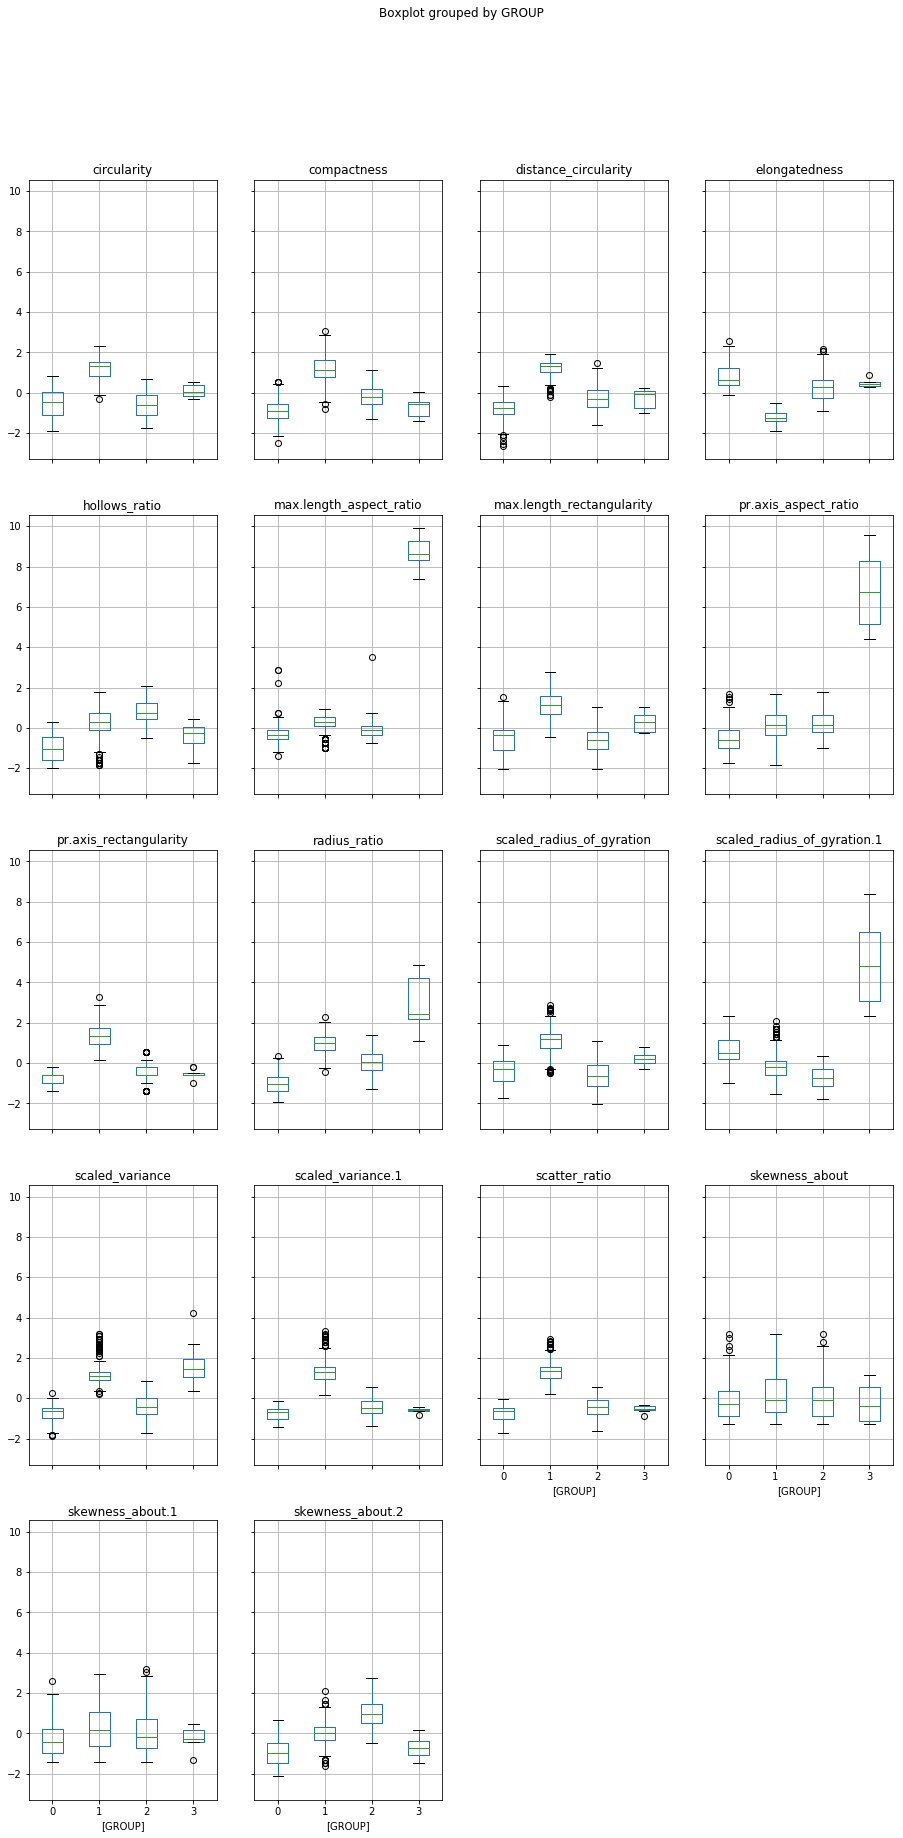

In [176]:
vehicle_df.boxplot(by = 'GROUP',  layout=(5,4), figsize=(15, 30))

### Using optimal value of K - Cluster the data. 
Note: Since the data has more than 2 dimension we cannot visualize the data. As an alternative, we can observe the centroids and note how they are distributed across different dimensions

In [177]:
centroids

array([[-8.73939377e-01, -4.90666958e-01, -8.19987596e-01,
        -1.00914774e+00, -4.88356546e-01, -2.75961304e-01,
        -7.59559699e-01,  8.28143534e-01, -7.31863992e-01,
        -4.54863559e-01, -7.72863866e-01, -7.64634145e-01,
        -3.79292105e-01,  6.60977993e-01, -1.09968514e-01,
        -2.97172612e-01, -9.41479276e-01, -9.74511472e-01,
        -1.07163989e+00],
       [ 1.15442786e+00,  1.18428647e+00,  1.21198691e+00,
         9.73321772e-01,  9.49213388e-02,  2.18659142e-01,
         1.29796844e+00, -1.21424667e+00,  1.30184458e+00,
         1.09830595e+00,  1.20590258e+00,  1.30898668e+00,
         1.09121291e+00, -1.07878646e-01,  1.68326262e-01,
         2.67954844e-01,  4.67043879e-03,  1.90327006e-01,
        -2.75256681e-01],
       [-1.80058424e-01, -6.16152564e-01, -3.01440484e-01,
         1.73860874e-02,  2.01842965e-01, -1.81244620e-01,
        -4.34747954e-01,  2.89699607e-01, -4.65512286e-01,
        -5.77905578e-01, -4.00561016e-01, -4.38400195e-01,
    

You can use kmeans.cluster_centers_ function to pull the centroid information from the instance

### 7. Store the centroids in a dataframe with column names from the original dataset given 

In [178]:
centroid_df = pd.DataFrame(centroids, columns = list(vehicle_df_attributes) )
centroid_df

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,GROUP
0,-0.873939,-0.490667,-0.819988,-1.009148,-0.488357,-0.275961,-0.759560,0.828144,-0.731864,-0.454864,-0.772864,-0.764634,-0.379292,0.660978,-0.109969,-0.297173,-0.941479,-0.974511,-1.071640
1,1.154428,1.184286,1.211987,0.973322,0.094921,0.218659,1.297968,-1.214247,1.301845,1.098306,1.205903,1.308987,1.091213,-0.107879,0.168326,0.267955,0.004670,0.190327,-0.275257
2,-0.180058,-0.616153,-0.301440,0.017386,0.201843,-0.181245,-0.434748,0.289700,-0.465512,-0.577906,-0.400561,-0.438400,-0.645061,-0.707581,-0.038874,0.054655,0.961223,0.813490,1.317510
3,-0.733024,0.072735,-0.272171,2.947683,6.836652,8.696706,-0.535008,0.466248,-0.557406,0.283411,1.697528,-0.588068,0.212701,4.965638,-0.274839,-0.231193,-0.707994,-0.453651,0.521127


Hint: Use pd.Dataframe function 

### Use kmeans.labels_ function to print out the labels of the classes

In [179]:
final_model.labels_

array([2, 2, 1, 2, 3, 2, 2, 2, 2, 2, 2, 0, 2, 1, 0, 2, 1, 0, 0, 2, 2, 1,
       2, 0, 1, 1, 0, 0, 2, 2, 1, 2, 0, 3, 1, 0, 1, 0, 0, 2, 1, 0, 0, 0,
       0, 2, 0, 2, 1, 2, 1, 2, 2, 0, 1, 0, 1, 0, 0, 0, 2, 0, 1, 2, 1, 1,
       2, 0, 2, 1, 2, 0, 0, 1, 2, 0, 2, 1, 2, 0, 2, 0, 1, 2, 1, 0, 0, 1,
       0, 0, 1, 0, 3, 2, 2, 0, 1, 1, 0, 0, 1, 2, 0, 0, 0, 0, 2, 1, 1, 2,
       0, 0, 2, 0, 0, 0, 0, 0, 2, 1, 1, 2, 2, 0, 1, 3, 0, 2, 0, 2, 2, 1,
       0, 2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 2, 1, 2, 0, 2, 0, 1, 2, 0, 1, 1,
       2, 1, 0, 0, 1, 1, 2, 1, 0, 2, 2, 2, 0, 1, 0, 2, 0, 1, 2, 2, 2, 1,
       2, 1, 2, 1, 2, 0, 1, 0, 0, 0, 0, 2, 1, 1, 2, 0, 2, 0, 1, 2, 0, 2,
       1, 0, 0, 1, 0, 2, 1, 0, 0, 0, 2, 1, 2, 1, 0, 0, 0, 0, 1, 2, 0, 2,
       1, 0, 2, 2, 0, 1, 0, 0, 2, 2, 1, 0, 1, 0, 2, 0, 1, 2, 2, 1, 1, 0,
       2, 2, 2, 1, 0, 2, 2, 0, 0, 2, 2, 1, 2, 0, 0, 1, 2, 2, 0, 0, 1, 0,
       0, 1, 0, 0, 3, 0, 2, 1, 2, 1, 0, 2, 2, 1, 2, 2, 2, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 2, 0, 1, 1, 0, 1, 2, 0,

## Hierarchical Clustering 

### 8. Variable creation

For Hierarchical clustering, we will create datasets using multivariate normal distribution to visually observe how the clusters are formed at the end

In [180]:
a = np.random.multivariate_normal([10, 0], [[3, 1], [1, 4]], size=[100,])
b = np.random.multivariate_normal([0, 20], [[3, 1], [1, 4]], size=[50,])
c = np.random.multivariate_normal([10, 20], [[3, 1], [1, 4]], size=[100,])

### 9. Combine all three arrays a,b,c into a dataframe

In [181]:
X = np.concatenate((a, b,c),)

X.shape

(250, 2)

In [182]:
df = pd.DataFrame(X, columns=["col1", "col2"])
df.head()

,col1,col2
0,10.163415,0.858402
1,11.086092,-2.543705
2,9.513123,-2.488262
3,12.558494,0.074376
4,10.581637,0.271359


### 10. Use scatter matrix to print all the 3 distributions

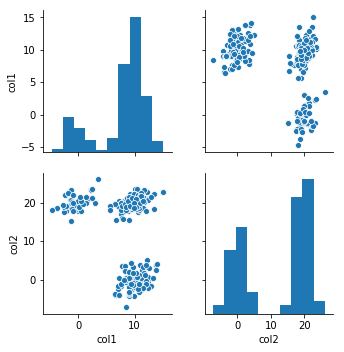

In [183]:
sns.pairplot(df)

### 11. Find out the linkage matrix

Use ward as linkage metric and distance as Eucledian

In [184]:
# generate the linkage matrix
Z = linkage(df, method='ward',metric='euclidean')

Z

array([[1.70000000e+02, 2.19000000e+02, 1.21702039e-02, 2.00000000e+00],
       [2.10000000e+01, 4.10000000e+01, 4.12645827e-02, 2.00000000e+00],
       [1.62000000e+02, 1.75000000e+02, 5.71402496e-02, 2.00000000e+00],
       [1.06000000e+02, 1.38000000e+02, 5.91021118e-02, 2.00000000e+00],
       [6.70000000e+01, 7.20000000e+01, 6.74588520e-02, 2.00000000e+00],
       [2.00000000e+01, 8.70000000e+01, 7.95333379e-02, 2.00000000e+00],
       [1.76000000e+02, 2.07000000e+02, 8.90708987e-02, 2.00000000e+00],
       [1.92000000e+02, 2.43000000e+02, 9.12367670e-02, 2.00000000e+00],
       [1.64000000e+02, 1.93000000e+02, 9.13479687e-02, 2.00000000e+00],
       [8.50000000e+01, 9.80000000e+01, 1.03476037e-01, 2.00000000e+00],
       [1.00000000e+01, 9.90000000e+01, 1.04649999e-01, 2.00000000e+00],
       [1.28000000e+02, 1.46000000e+02, 1.16581053e-01, 2.00000000e+00],
       [1.53000000e+02, 2.08000000e+02, 1.18285179e-01, 2.00000000e+00],
       [4.90000000e+01, 6.40000000e+01, 1.24350353e

In [185]:
# cophenet index is a measure of the correlation between the distance of points in feature space and distance on dendrogram
# closer it is to 1, the better is the clustering
c, coph_dists = cophenet(Z , pdist(df))

print("Cophenetic Correlation Co-efficient : {0}".format(c))
print("Cophenetic Distance Matrix : {0}".format(coph_dists))

Cophenetic Correlation Co-efficient : 0.9563719523071315
Cophenetic Distance Matrix : [10.94265377 10.94265377  6.52846884 ...  1.17293269 12.97446487
 12.97446487]


### 12. Plot the dendrogram for the consolidated dataframe

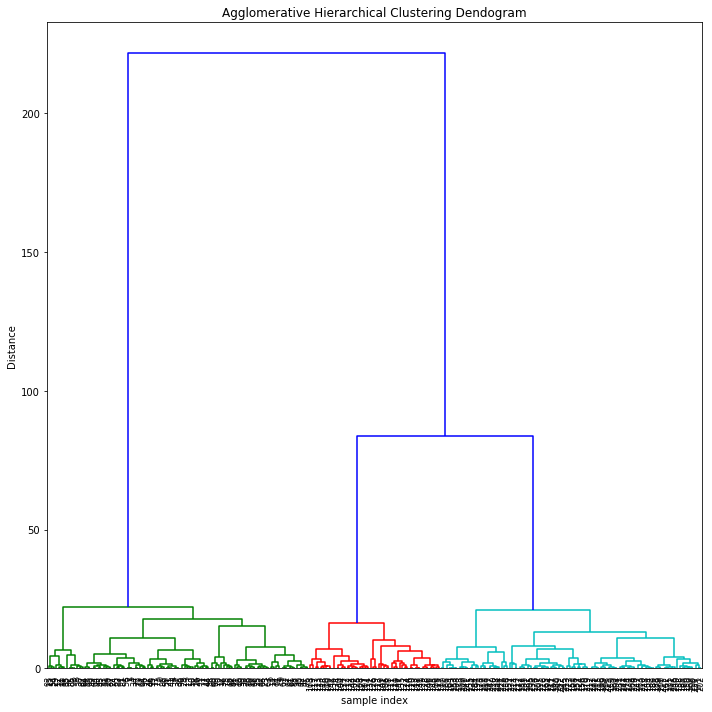

In [186]:
plt.figure(figsize=(10, 10))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, leaf_rotation=90.,color_threshold = 40, leaf_font_size=8. )
plt.tight_layout()

### 13. Recreate the dendrogram for last 12 merged clusters 

Hint: Use truncate_mode='lastp' attribute in dendrogram function to arrive at dendrogram 

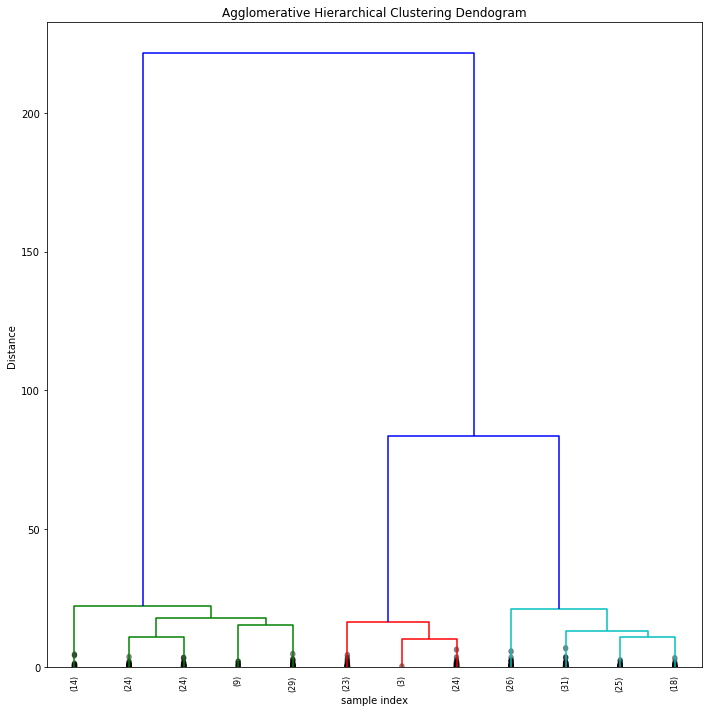

In [187]:
plt.figure(figsize=(10, 10))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, 
           leaf_rotation=90.,
           color_threshold = 40, 
           leaf_font_size=8.,
           truncate_mode='lastp',
           p=12,
           show_contracted=True)
plt.tight_layout()

### 14. From the truncated dendrogram, find out the optimal distance between clusters which u want to use an input for clustering data

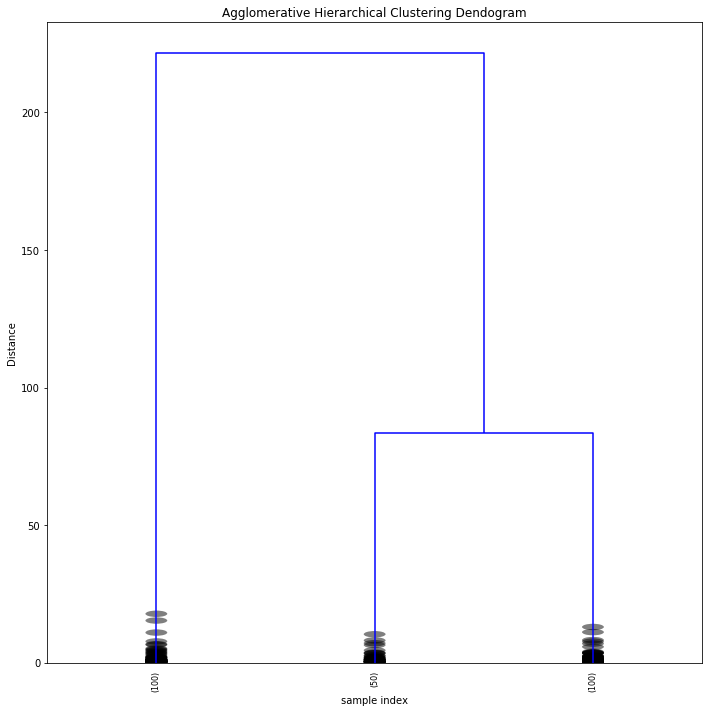

In [188]:
# As per the truncated dendogram the optimal value is 3

# Draw dendrogram with optimal value 3
plt.figure(figsize=(10, 10))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, 
           leaf_rotation=90.,
           color_threshold = 40, 
           leaf_font_size=8.,
           truncate_mode='lastp',
           p=3,
           show_contracted=True)
plt.tight_layout()

### 15. Using this distance measure and fcluster function to cluster the data into 3 different groups

In [189]:
max_d = 25
#forming flat clusters threshold value is 25 as per 
clusters = fcluster(Z, t=max_d, criterion='distance')
clusters

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3], dtype=int32)

### Use matplotlib to visually observe the clusters in 2D space 

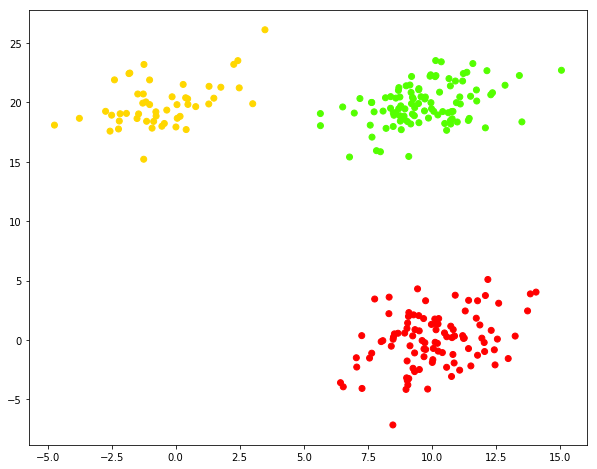

In [190]:
plt.figure(figsize=(10, 8))
plt.scatter(df["col1"], df["col2"], c=clusters, cmap='prism')  # plot points with cluster dependent colors
plt.show()